In [3]:
from sage.all import *

import numpy as np
import matplotlib.pyplot as plt

In [4]:

def compute_pdf_histogram(data: list[float], bins: int = 20) -> tuple[np.ndarray, np.ndarray]:

    density, bin_edges = np.histogram(data, bins=bins, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    return bin_centers, density


def compute_empirical_cdf(data):
    sorted_data = np.sort(np.array(data))
    n = len(sorted_data)
    cdf_values = np.arange(1, n + 1) / n
    
    return sorted_data, cdf_values

## Study of function $f_{\epsilon}$

In this notebook, we experimentaly verify the claims of appendix A.5  of the paper, regarding the distribution of the norms of $[s,t]$ smallest solutions of the equation $as + bt = c mod 4N$ for some fixed $a, b, N$ such that $\gcd(a, b, 2N)= 1$

In [5]:
def sample_lattice(e, skewed):
    while True: 
        N, a, b = 2, 2, 2
        while gcd(gcd(a, b), 4*N) != 1:
            N = randint(2**(e-2), 2**(e+2))
            a = randint(1, N)    
            b = randint(1, N)

        div_a = gcd(a, 4*N)
        N_mod = ZZ(4*N / div_a)
        a_inv = inverse_mod(ZZ(a/ div_a), N_mod)
        const = ZZ((b*a_inv) % N_mod)
        Lambda = Matrix(ZZ, [[-const, div_a], [N_mod, 0]])

        g, u, v = xgcd(a, b)
        vv, ss, _ = xgcd(g, 4*N)
        
        # assert we are working with a generator
        if vv != 1:
            print("divisors Pb")
            continue 
        
        Tar1, Tar2 = (u*ss), (ss*v)

        Lambda_reduced = Lambda.LLL() # reduce the lattice
        Lambda_inv = Matrix(QQ, Lambda_reduced).inverse()
        lambda_1 = Lambda_reduced.row(0).norm()
        lambda_2 = Lambda_reduced.row(1).norm()

        if lambda_1 <= sqrt(N/2):
            continue

        if skewed:
            if float(lambda_1/sqrt(4*N)) >= 0.6:
                continue
        else:
            if float(lambda_1/sqrt(4*N)) <= 0.85:
                continue

        print("First minima/2N = ", float(lambda_1/sqrt(4*N)))
        print("Second minima/2N = ", float(lambda_2/sqrt(4*N)))
        return N, a, b, Lambda_reduced, Lambda_inv, Tar1, Tar2
        
        
def sample_minima(N, a, b, Lambda_reduced, Lambda_inv, Tar1, Tar2, sampling):
    list_minima = []
    for k in range(sampling):
        c = randint(1, 4*N)
        c = ((c >> 1) << 1) + 1 #odd
        V1, V2 = (-c * Tar1) % (4*N), (-c * Tar2) % (4*N)
        assert((a*V1 + b*V2) % (4*N) == -c %(4*N))        
        v_target = vector(ZZ, [V1, V2])
        AB_vec = vector([round(c) for c in v_target*Lambda_inv])
        v_close = AB_vec*Lambda_reduced

        s, t = v_close - v_target
        assert((a*s + b*t) % (4*N) == c)
        list_minima.append(float(sqrt((s**2 + t**2)/N)))
    
    return list_minima

def plot_function(x,y, name):
    plt.figure(figsize=(8, 5))          # Set the figure size

    plt.plot(x, y, color='dodgerblue', linewidth=1, label='KDE Density')
    plt.fill_between(x, y, color='dodgerblue', alpha=0.1)

    plt.title(name, fontsize=14, pad=15)
    plt.xlabel('x', fontsize=10)
    plt.ylabel('y', fontsize=10)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    #plt.legend()
    plt.tight_layout()
    plt.show()

## Lattice with skewed minima

In [6]:

N_s,a_s,b_s, Lambda_reduced_s, Lambda_inv_s, Tar1_s, Tar2_s =  sample_lattice(128, True)


First minima/2N =  0.5655070469009602
Second minima/2N =  1.7684048830321246


In [7]:
list_minima =sample_minima(N_s,a_s,b_s, Lambda_reduced_s, Lambda_inv_s, Tar1_s, Tar2_s, 10**6)
list_minima_sort = sorted(list_minima)


In [8]:
#Compute its pdf/cdf
x_pdf, y_pdf = compute_pdf_histogram(list_minima_sort, bins=500)
x_cdf, y_cdf = compute_empirical_cdf(list_minima_sort)

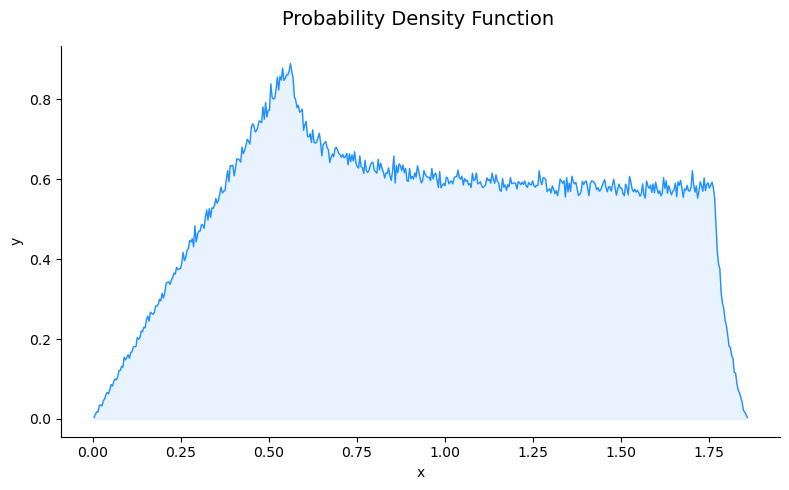

In [9]:
plot_function(x_pdf, y_pdf, "Probability Density Function ")

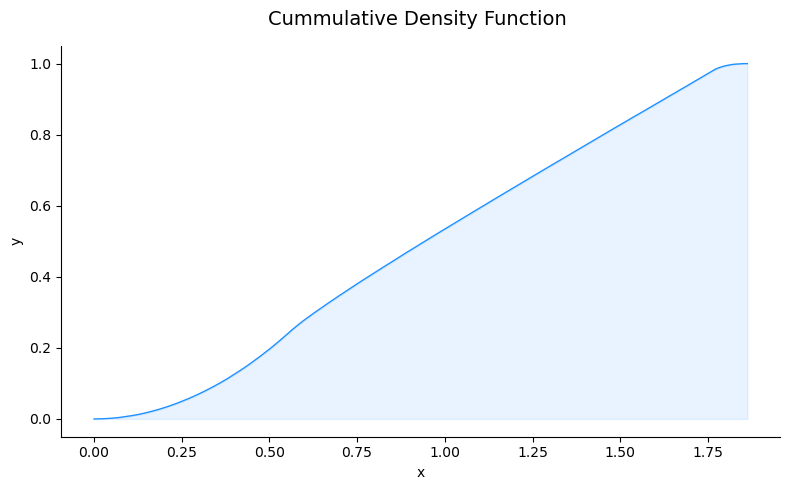

In [10]:
plot_function(x_cdf, y_cdf, "Cummulative Density Function ")

# lattice with equal minima

In [31]:
N_r,a_r,b_r, Lambda_reduced_r, Lambda_inv_r, Tar1_r, Tar2_r =  sample_lattice(128, False)


First minima/2N =  0.9854602289435802
Second minima/2N =  1.023250487821548


In [32]:
list_minima_regular =sample_minima(N_r,a_r,b_r, Lambda_reduced_r, Lambda_inv_r, Tar1_r, Tar2_r, 10**6)
list_minima_regular_sort = sorted(list_minima_regular)


In [33]:
#Compute its pdf
x_pdf_r, y_pdf_r = compute_pdf_histogram(list_minima_regular_sort, bins=500)
x_cdf_r, y_cdf_r = compute_empirical_cdf(list_minima_regular_sort)

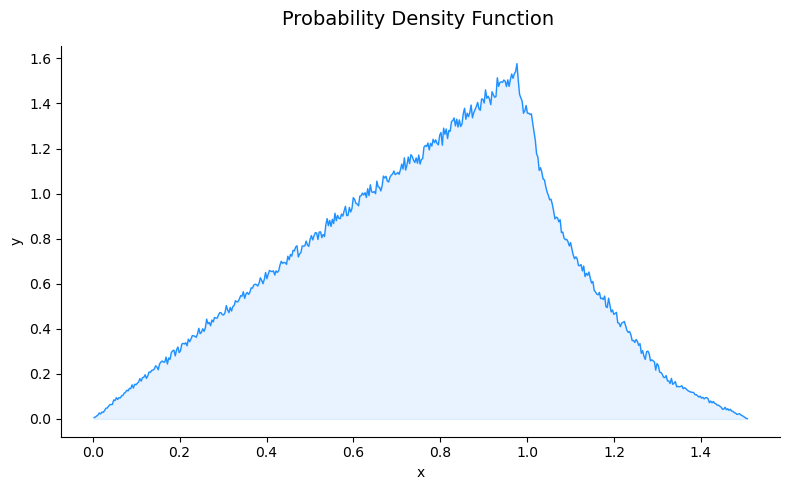

In [34]:
plot_function(x_pdf_r, y_pdf_r, "Probability Density Function ")

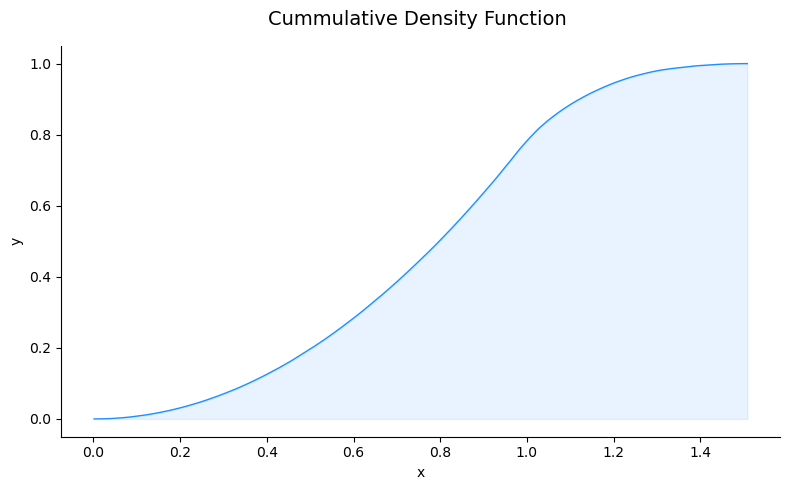

In [35]:
plot_function(x_cdf_r, y_cdf_r, "Cummulative Density Function ")

## Testing randomness of the target sampling

In [16]:
def sample_numbers(N, r0, sampling):
    list_samples = []
    numb = 0
    k = -1
    while numb <= sampling:
        k += 2
        if gcd(k,2*N) != 1:
            continue
        numb += 1
        k_inv = inverse_mod(k, N)
        c = ZZ((k_inv*2**250 - 2*r0*k + N) % (4*N))
        
        list_samples.append(float(c / (4*N)))
    
    return list_samples

 

In [17]:
N_t = randint(1,2**130)
r0 = randint(1,2**130)

In [18]:
list_sampling = sample_numbers(N_t,r0, 10**7)
list_sampling_sort = sorted(list_sampling)


In [23]:
x_pdf_sampling, y_pdf_sampling = compute_pdf_histogram(list_sampling_sort, bins=500)
x_cdf_sampling, y_cdf_sampling = compute_empirical_cdf(list_sampling_sort)

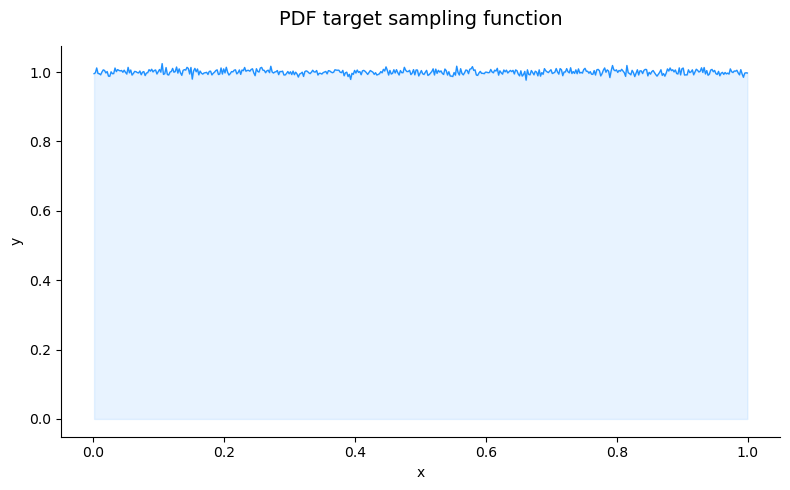

In [24]:
plot_function(x_pdf_sampling, y_pdf_sampling, "PDF target sampling function")

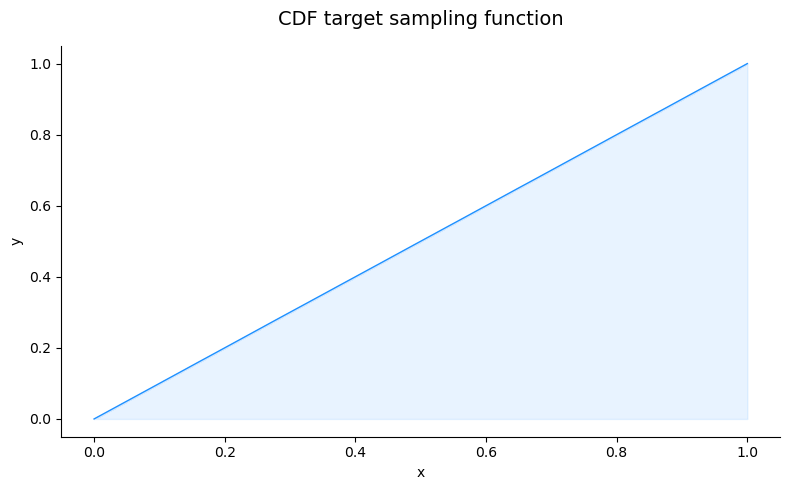

In [25]:
plot_function(x_cdf_sampling, y_cdf_sampling, "CDF target sampling function")